In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from src.fluid      import Fluid
from src.interpolator import LinearInterpolator
from src.reservoir  import ResProps, Reservoir
from src.pipe       import Pipe
from src.well       import Well
from src.compressor import DCS
from src.simulator import FieldSimulator

plt.rcParams['axes.grid'] = True

In [2]:
M = 0.016
T_res = 310.0
df = pd.read_csv('hw2_data.csv', sep=';')
xa = df['xa, mol. %'].iloc[13]
xy = df['xy, mol. %'].iloc[13]
rho_c = df['rho_c, kg/m3'].iloc[13]

fluid = Fluid(M=M, rho_c=rho_c, xa=xa, xy=xy, T=T_res)

In [3]:
import math
roughness = 0.000046  # m

# Пласт (общий для всех трёх скважин)
P0    = 100.0   # atm
V_res = math.pi * 500**2 * 25   # m³

# NKT Скважины
nkt_1 = Pipe(L=2000, D=0.062, roughness=roughness, fluid=fluid, vertical_depth=1800)
nkt_2 = Pipe(L=2500, D=0.062, roughness=roughness, fluid=fluid, vertical_depth=1900)
nkt_3 = Pipe(L=1800, D=0.073, roughness=roughness, fluid=fluid, vertical_depth=1600)

# Скважины: [k, h, re, rw]
well_1 = Well(fluid=fluid, k=50, h=25, re=500, rw=0.1, pipe=nkt_1)
well_2 = Well(fluid=fluid, k=50, h=25, re=500, rw=0.1, pipe=nkt_2)
well_3 = Well(fluid=fluid, k=50, h=25, re=500, rw=0.1, pipe=nkt_3)
wells = [well_1, well_2, well_3]

# Шлейф
shlyf = Pipe(L=5000, D=0.200, roughness=roughness, fluid=fluid, vertical_depth=0)

# ДКС
CR     = 1.5
P_line = 5.0    # atm
q_ext  = 500.0  # ст.м³/сут
dcs   = DCS(CR=CR, P_line=P_line, q_ext=q_ext)

resprops = ResProps(P=P0, V=V_res, T=T_res)
reservoir = Reservoir(resprops=resprops, fluid=fluid)
simulate = FieldSimulator(reservoir=reservoir, wells=wells, shlyf=shlyf, dcs=dcs)

# Раздел 1 — Модель PVT

Графики Z(P), Bg(P), mu(P), ρ(P) в диапазоне 1–200 атм.

Сравнение ρ_ideal vs ρ_real

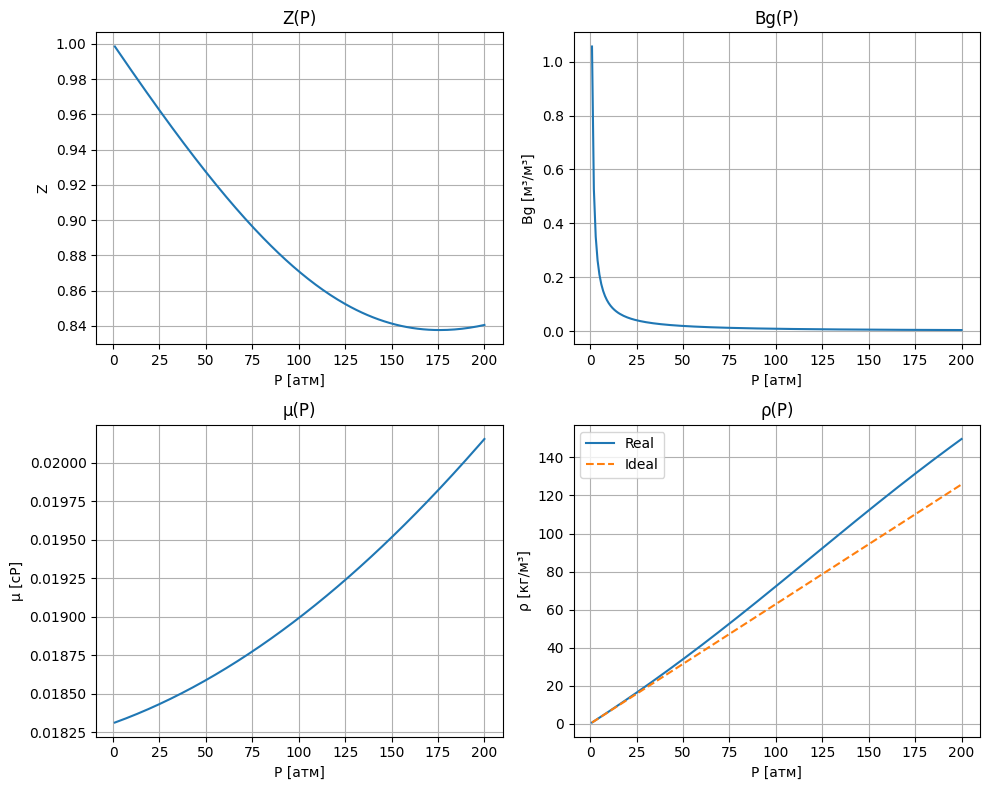

In [4]:
P_range = np.linspace(1, 200, 200)

Z_vals   = [fluid.z(P)   for P in P_range]
Bg_vals  = [fluid.bg(P)  for P in P_range]
mu_vals  = [fluid.mu(P)  for P in P_range]
rho_vals = [fluid.ro(P)  for P in P_range]

R = 8.314
rho_ideal = [P * 101325 * M / (1.0 * R * T_res) for P in P_range]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

#Графики Z(P), Bg(P), mu(P)
axes[0,0].plot(P_range, Z_vals);   axes[0,0].set(title='Z(P)', xlabel='P [атм]', ylabel='Z')
axes[0,1].plot(P_range, Bg_vals);  axes[0,1].set(title='Bg(P)', xlabel='P [атм]', ylabel='Bg [м³/м³]')
axes[1,0].plot(P_range, mu_vals);  axes[1,0].set(title='μ(P)', xlabel='P [атм]', ylabel='μ [cP]')
#ρ(P), cравнение ρ_ideal vs ρ_real
axes[1,1].plot(P_range, rho_vals, label='Real')
axes[1,1].plot(P_range, rho_ideal, '--', label='Ideal')
axes[1,1].set(title='ρ(P)', xlabel='P [атм]', ylabel='ρ [кг/м³]')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Раздел 2 — Модель пласта

кривая IPR при P_res = 100 атм для одной скважины.

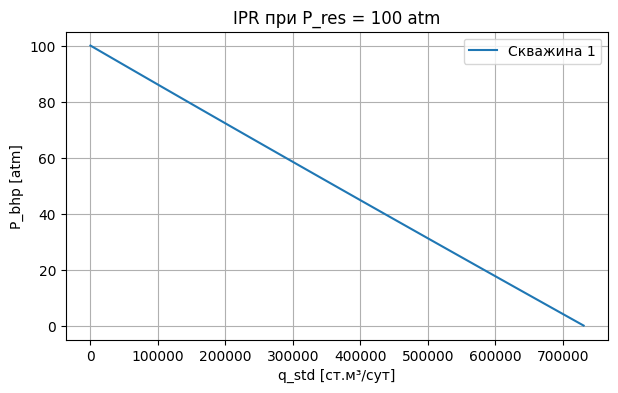

In [5]:
P_res = 100
P_bhp_range = np.linspace(0, P_res, 100)
q_ipr = [well_1.q(P_res, P_bhp) for P_bhp in P_bhp_range]


fig, axes = plt.subplots(figsize=(7, 4))
axes.plot(q_ipr, P_bhp_range, label=f'Скважина 1')
axes.set(xlabel='q_std [ст.м³/сут]', ylabel='P_bhp [atm]',
       title=f'IPR при P_res = {P_res} atm')
axes.legend()
plt.show()

# Раздел 3 — Гидравлика

кривые VLP трёх скважин и шлейфа. Зависимость λ(Re) по Колбруку–Уайту.

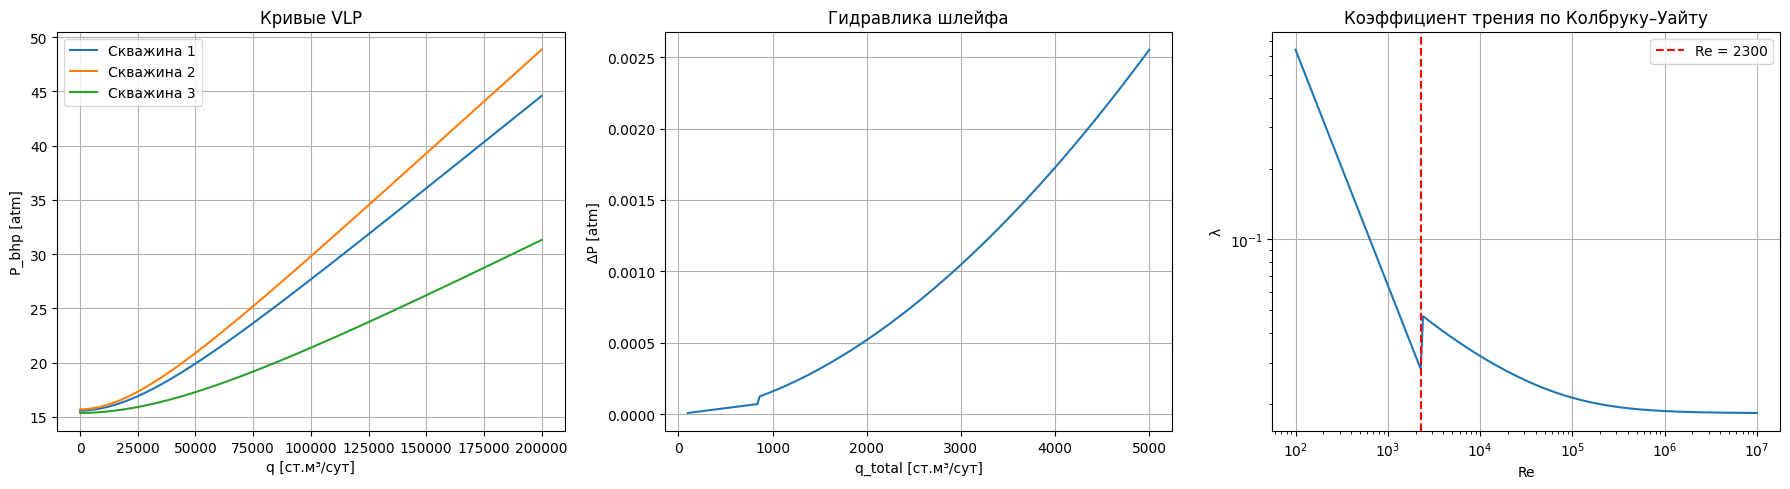

In [6]:
q_range  = np.linspace(0, 200000, 200)
states_0 = simulate.solve(P_res=P0)

# VLP скважин
P_man_1 = states_0['well_1'].P_out
P_man_2 = states_0['well_2'].P_out
P_man_3 = states_0['well_3'].P_out

P_bhp_vlp_1 = [simulate.calc_P_bhp(well_1, P_man_1, q)[0] for q in q_range]
P_bhp_vlp_2 = [simulate.calc_P_bhp(well_2, P_man_2, q)[0] for q in q_range]
P_bhp_vlp_3 = [simulate.calc_P_bhp(well_3, P_man_3, q)[0] for q in q_range]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(q_range, P_bhp_vlp_1, label='Скважина 1')
axes[0].plot(q_range, P_bhp_vlp_2, label='Скважина 2')
axes[0].plot(q_range, P_bhp_vlp_3, label='Скважина 3')
axes[0].set(xlabel='q [ст.м³/сут]', ylabel='P_bhp [atm]', title='Кривые VLP')
axes[0].legend()

#шлейф
q_shlyf = np.linspace(100, 5000, 200)
dP_shlyf = [shlyf.dp(dcs.P_in(), q).dP for q in q_shlyf]

axes[1].plot(q_shlyf, dP_shlyf)
axes[1].set(xlabel='q_total [ст.м³/сут]', ylabel='ΔP [atm]', title='Гидравлика шлейфа')

# λ(Re)
Re_range     = np.logspace(2, 7, 200)
lambda_vals  = [nkt_1.f_lambda(Re) for Re in Re_range]

axes[2].loglog(Re_range, lambda_vals)
axes[2].axvline(2300, color='r', linestyle='--', label='Re = 2300')
axes[2].set(xlabel='Re', ylabel='λ', title='Коэффициент трения по Колбруку–Уайту')
axes[2].legend()

plt.tight_layout()
plt.show()

# Раздел 4 — Рабочая точка

графики IPR + VLP для каждой скважины с отмеченной рабочей точкой.

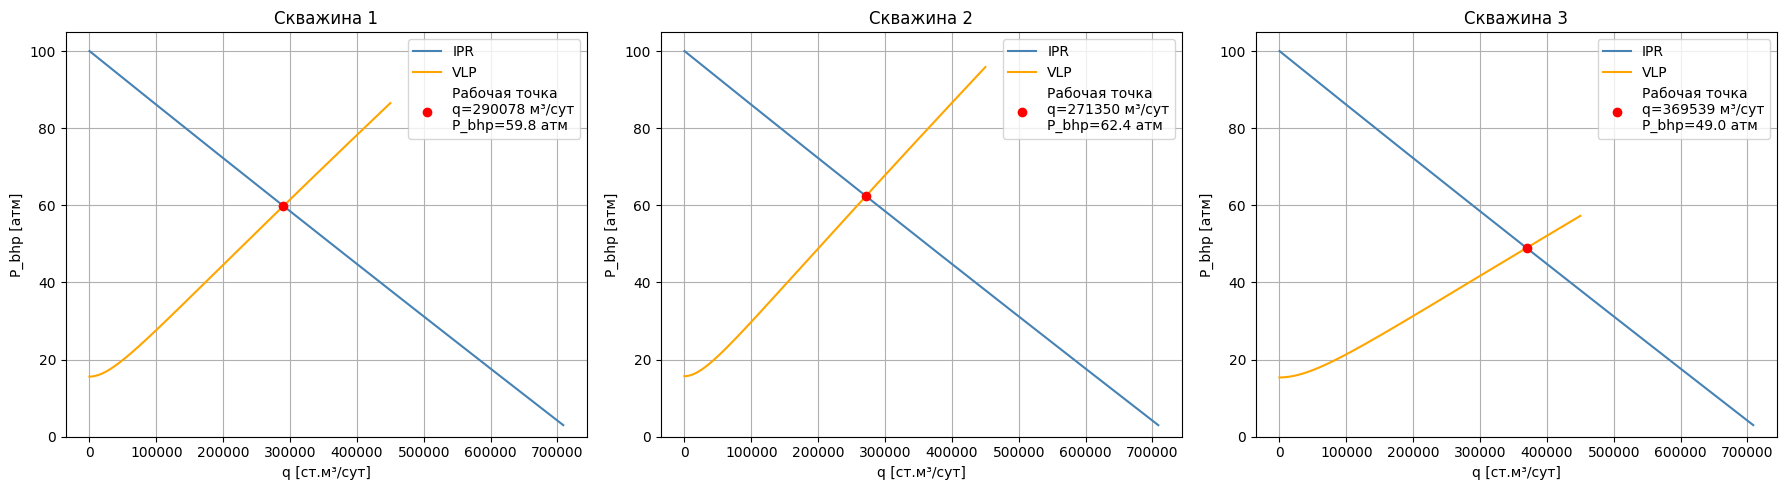

In [7]:
P_bhp_range = np.linspace(3, P0, 200)
q_range     = np.linspace(0, 450000, 200)

# Скважина 1
P_man_1     = states_0['well_1'].P_out
q_sol_1     = states_0['well_1'].q_std
P_bhp_sol_1 = states_0['well_1'].P_in

q_ipr_1     = [well_1.q(P0, Pb) for Pb in P_bhp_range]
P_bhp_vlp_1 = [simulate.calc_P_bhp(well_1, P_man_1, q)[0] for q in q_range]

# Скважина 2
P_man_2     = states_0['well_2'].P_out
q_sol_2     = states_0['well_2'].q_std
P_bhp_sol_2 = states_0['well_2'].P_in

q_ipr_2     = [well_2.q(P0, Pb) for Pb in P_bhp_range]
P_bhp_vlp_2 = [simulate.calc_P_bhp(well_2, P_man_2, q)[0] for q in q_range]

# Скважина 3 
P_man_3     = states_0['well_3'].P_out
q_sol_3     = states_0['well_3'].q_std
P_bhp_sol_3 = states_0['well_3'].P_in

q_ipr_3     = [well_3.q(P0, Pb) for Pb in P_bhp_range]
P_bhp_vlp_3 = [simulate.calc_P_bhp(well_3, P_man_3, q)[0] for q in q_range]

#Графики 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(q_ipr_1, P_bhp_range, label='IPR', color='steelblue')
axes[0].plot(q_range, P_bhp_vlp_1, label='VLP', color='orange')
axes[0].scatter([q_sol_1], [P_bhp_sol_1], color='red', zorder=5,
                label=f'Рабочая точка\nq={q_sol_1:.0f} м³/сут\nP_bhp={P_bhp_sol_1:.1f} атм')
axes[0].set(title='Скважина 1', xlabel='q [ст.м³/сут]', ylabel='P_bhp [атм]')
axes[0].set_ylim(bottom=0)
axes[0].legend()

axes[1].plot(q_ipr_2, P_bhp_range, label='IPR', color='steelblue')
axes[1].plot(q_range, P_bhp_vlp_2, label='VLP', color='orange')
axes[1].scatter([q_sol_2], [P_bhp_sol_2], color='red', zorder=5,
                label=f'Рабочая точка\nq={q_sol_2:.0f} м³/сут\nP_bhp={P_bhp_sol_2:.1f} атм')
axes[1].set(title='Скважина 2', xlabel='q [ст.м³/сут]', ylabel='P_bhp [атм]')
axes[1].set_ylim(bottom=0)
axes[1].legend()

axes[2].plot(q_ipr_3, P_bhp_range, label='IPR', color='steelblue')
axes[2].plot(q_range, P_bhp_vlp_3, label='VLP', color='orange')
axes[2].scatter([q_sol_3], [P_bhp_sol_3], color='red', zorder=5,
                label=f'Рабочая точка\nq={q_sol_3:.0f} м³/сут\nP_bhp={P_bhp_sol_3:.1f} атм')
axes[2].set(title='Скважина 3', xlabel='q [ст.м³/сут]', ylabel='P_bhp [атм]')
axes[2].set_ylim(bottom=0)
axes[2].legend()

plt.tight_layout()
plt.show()

# Раздел 5 — Динамика 

графики Pres(t), Pman(t), q1(t), q2(t), q3(t), Gp(t) на 180 дней.

ЗАПУСК СИМУЛЯЦИИ
День   1: P_res = 100.00 атм, q_total =   930968 м³/сут, Gp = 931.0 тыс. м³
День  10: P_res = 100.00 атм, q_total =   930919 м³/сут, Gp = 9309.4 тыс. м³
День  20: P_res =  99.99 атм, q_total =   930866 м³/сут, Gp = 18618.3 тыс. м³
День  30: P_res =  99.99 атм, q_total =   930812 м³/сут, Gp = 27926.7 тыс. м³
День  40: P_res =  99.99 атм, q_total =   930759 м³/сут, Gp = 37234.5 тыс. м³
День  50: P_res =  99.98 атм, q_total =   930705 м³/сут, Gp = 46541.8 тыс. м³
День  60: P_res =  99.98 атм, q_total =   930652 м³/сут, Gp = 55848.6 тыс. м³
День  70: P_res =  99.97 атм, q_total =   930598 м³/сут, Gp = 65154.8 тыс. м³
День  80: P_res =  99.97 атм, q_total =   930545 м³/сут, Gp = 74460.5 тыс. м³
День  90: P_res =  99.97 атм, q_total =   930491 м³/сут, Gp = 83765.6 тыс. м³
День 100: P_res =  99.96 атм, q_total =   930438 м³/сут, Gp = 93070.3 тыс. м³
День 110: P_res =  99.96 атм, q_total =   930384 м³/сут, Gp = 102374.3 тыс. м³
День 120: P_res =  99.95 атм, q_total =   930331 

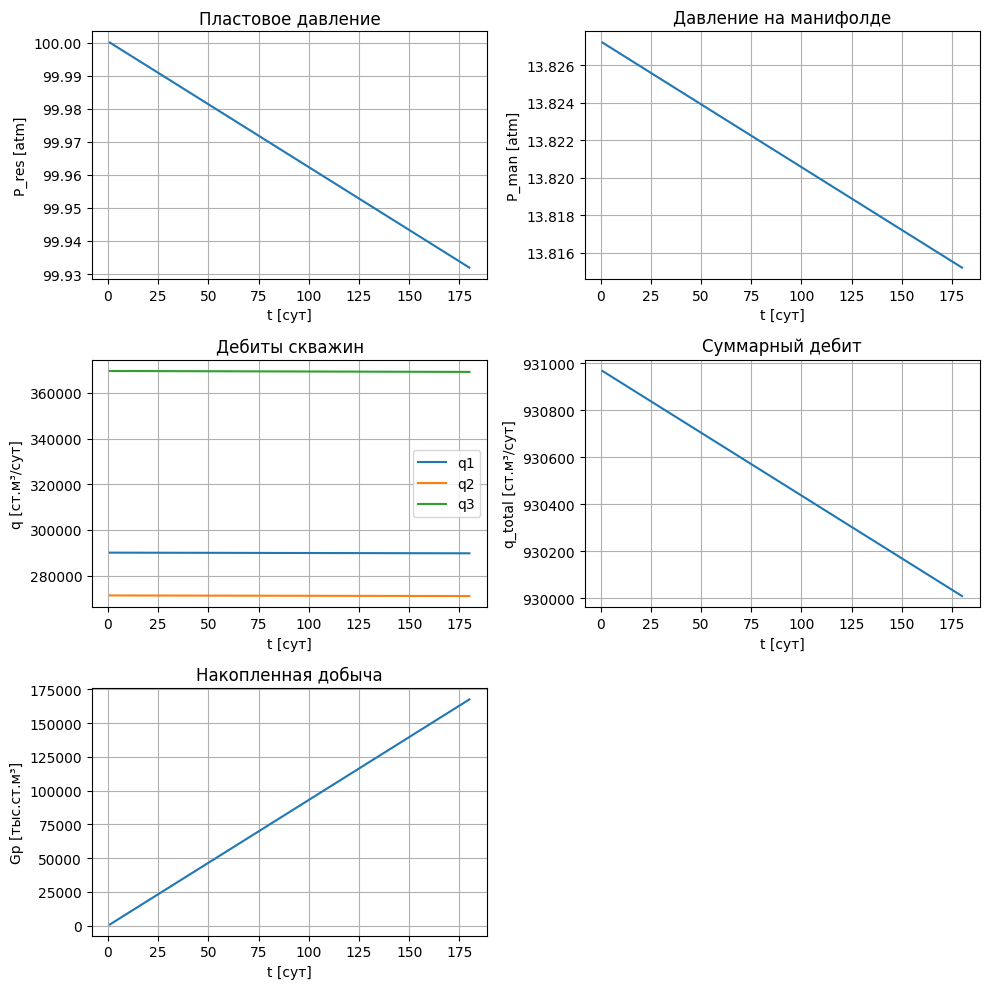

In [8]:
reservoir.resprops.P = P0
df = simulate.run(N_days=180, dt=1.0)

fig, axes = plt.subplots(3, 2, figsize=(10, 10))

axes[0,0].plot(df['t'], df['P_res'])
axes[0,0].set(xlabel = 't [сут]', ylabel='P_res [atm]', title='Пластовое давление')

axes[0,1].plot(df['t'], df['P_man'])
axes[0,1].set(xlabel = 't [сут]', ylabel='P_man [atm]', title='Давление на манифолде')

axes[1,0].plot(df['t'], df['q1'], label='q1')
axes[1,0].plot(df['t'], df['q2'], label='q2')
axes[1,0].plot(df['t'], df['q3'], label='q3')
axes[1,0].set(xlabel = 't [сут]', ylabel='q [ст.м³/сут]', title='Дебиты скважин')
axes[1,0].legend()

axes[1,1].plot(df['t'], df['q_total']); 
axes[1,1].set(xlabel = 't [сут]', ylabel='q_total [ст.м³/сут]', title='Суммарный дебит')

axes[2,0].plot(df['t'], df['Gp'])
axes[2,0].set(xlabel = 't [сут]', ylabel='Gp [тыс.ст.м³]', title='Накопленная добыча')

axes[2,1].axis('off')

plt.tight_layout()
plt.show()

# Раздел 6 — Влияние ДКС

сравнение динамики при CR ∈ 1.0, 1.5, 2.0, 3.0.



── CR = 1.0 ──
ЗАПУСК СИМУЛЯЦИИ
День   1: P_res = 100.00 атм, q_total =   924784 м³/сут, Gp = 924.8 тыс. м³
День  10: P_res = 100.00 атм, q_total =   924736 м³/сут, Gp = 9247.6 тыс. м³
День  20: P_res =  99.99 атм, q_total =   924683 м³/сут, Gp = 18494.7 тыс. м³
День  30: P_res =  99.99 атм, q_total =   924630 м³/сут, Gp = 27741.2 тыс. м³
День  40: P_res =  99.99 атм, q_total =   924577 м³/сут, Gp = 36987.2 тыс. м³
День  50: P_res =  99.98 атм, q_total =   924523 м³/сут, Gp = 46232.7 тыс. м³
День  60: P_res =  99.98 атм, q_total =   924470 м³/сут, Gp = 55477.6 тыс. м³
День  70: P_res =  99.97 атм, q_total =   924417 м³/сут, Gp = 64722.0 тыс. м³
День  80: P_res =  99.97 атм, q_total =   924364 м³/сут, Gp = 73965.9 тыс. м³
День  90: P_res =  99.97 атм, q_total =   924311 м³/сут, Gp = 83209.3 тыс. м³
День 100: P_res =  99.96 атм, q_total =   924258 м³/сут, Gp = 92452.1 тыс. м³
День 110: P_res =  99.96 атм, q_total =   924205 м³/сут, Gp = 101694.4 тыс. м³
День 120: P_res =  99.96 атм, q_t

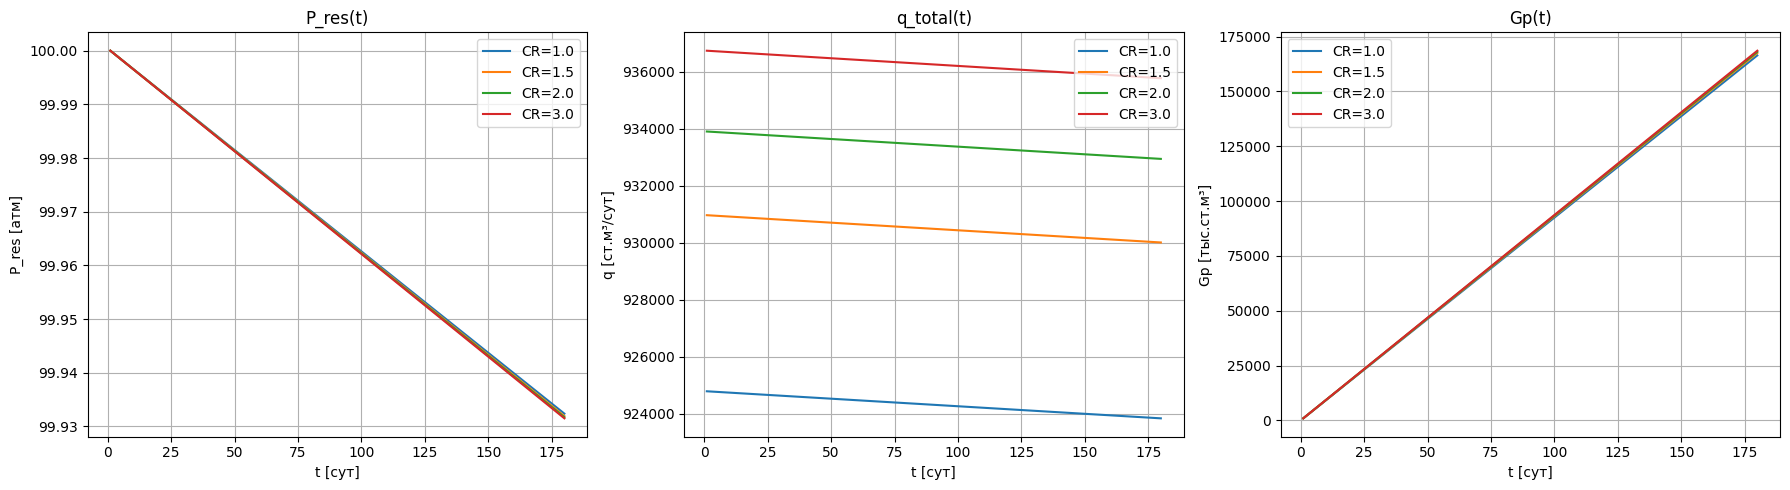

In [9]:
CR_values = [1.0, 1.5, 2.0, 3.0]
results_cr = {}

for cr in CR_values:
    reservoir.resprops.P = P0
    dcs.CR = cr
    print(f'\n── CR = {cr} ──')
    df_cr = simulate.run(N_days=180, dt=1.0)
    results_cr[cr] = df_cr

# Восстанавливаем исходное значение CR
dcs.CR = 1.5

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for cr, df_cr in results_cr.items():
    axes[0].plot(df_cr['t'], df_cr['P_res'],   label=f'CR={cr}')
    axes[1].plot(df_cr['t'], df_cr['q_total'], label=f'CR={cr}')
    axes[2].plot(df_cr['t'], df_cr['Gp'],      label=f'CR={cr}')

axes[0].set(title='P_res(t)',   xlabel='t [сут]', ylabel='P_res [атм]')
axes[1].set(title='q_total(t)', xlabel='t [сут]', ylabel='q [ст.м³/сут]')
axes[2].set(title='Gp(t)',      xlabel='t [сут]', ylabel='Gp [тыс.ст.м³]')

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()

# Раздел 7 — Калибровка

график «факт vs модель» по данным adapt_gdi_11-2025.csv, значения R² и RMSE.


C_corr оптимальный: 113.4698
R²   = 0.9708
RMSE = 2503.37 м³/сут


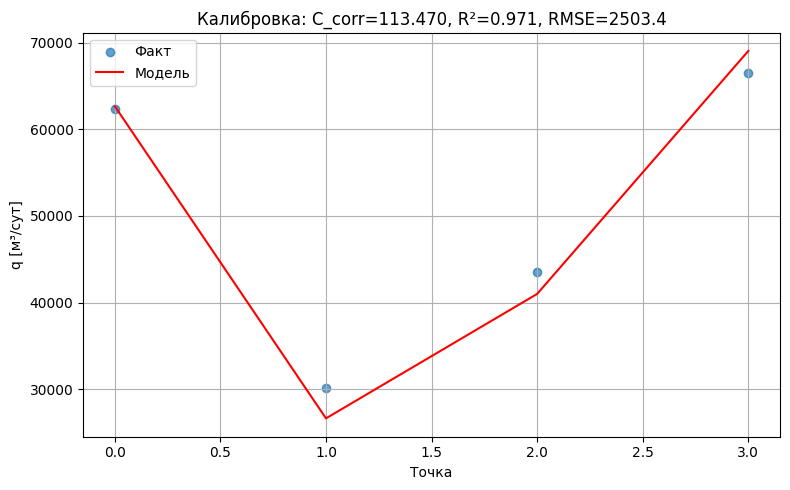

In [10]:
df_fact    = pd.read_csv('adapt_gdi_11-2025.csv', sep=',')
q_fact     = df_fact['q'].values
P_res_fact = df_fact['p_res'].values
P_bhp_fact = df_fact['p_bhp'].values

def q_simulado(C_corr):
    q_model = []
    for Pr, Pb in zip(P_res_fact, P_bhp_fact):
        C1 = well_1.productivity_coef(Pr, Pb)
        C2 = well_2.productivity_coef(Pr, Pb)
        C3 = well_3.productivity_coef(Pr, Pb)
        q  = C_corr * (C1 + C2 + C3) * (Pr - Pb)
        q_model.append(q)
    return np.array(q_model)

def calcular_rmse(X):
    return np.sqrt(np.mean((q_simulado(X[0]) - q_fact)**2))

result = minimize(calcular_rmse, x0=[1.0], method='Nelder-Mead')
C_opt  = result.x[0]
print(f'\nC_corr оптимальный: {C_opt:.4f}')

q_opt = q_simulado(C_opt)

ss_res = np.sum((q_fact - q_opt)**2)
ss_tot = np.sum((q_fact - np.mean(q_fact))**2)
R2   = 1 - ss_res / ss_tot
RMSE = np.sqrt(np.mean((q_fact - q_opt)**2))
print(f'R²   = {R2:.4f}')
print(f'RMSE = {RMSE:.2f} м³/сут')

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(range(len(q_fact)), q_fact, label='Факт',   alpha=0.7)
ax.plot(   range(len(q_opt)),  q_opt,  label='Модель', color='red')
ax.set(xlabel='Точка', ylabel='q [м³/сут]',
       title=f'Калибровка: C_corr={C_opt:.3f}, R²={R2:.3f}, RMSE={RMSE:.1f}')
ax.legend()

plt.tight_layout()
plt.show()